In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from omegaconf import OmegaConf

def collect_sweep_results(multirun_dir):
    rows = []
    base_path = Path(multirun_dir)
    
    if not base_path.exists():
        print(f"Error: Directory not found: {base_path}")
        return pd.DataFrame()

    # config.yaml を再帰的に探索
    config_files = list(base_path.rglob("config.yaml"))
    print(f"Found {len(config_files)} config files. Starting data collection...")

    for config_path in config_files:
        # .hydra フォルダ内の config か、直接の出力かを確認
        # 通常 Hydra は job_dir/.hydra/config.yaml に保存する
        job_dir = config_path.parent.parent if ".hydra" in str(config_path) else config_path.parent
        data_path = job_dir / "data" / "classification_results.npz"
        
        # 結果ファイルが存在する場合のみ処理
        if data_path.exists():
            try:
                cfg = OmegaConf.load(config_path)
                data = np.load(data_path)
                
                # --- パラメータ取得 (0を正しく扱うための厳密な判定) ---
                # syn_loc_mean
                mean_val = cfg.get('syn_loc_mean')
                if mean_val is None and 'task' in cfg:
                    mean_val = cfg.task.get('syn_loc_mean')
                
                # syn_loc_std
                std_val = cfg.get('syn_loc_std')
                if std_val is None and 'task' in cfg:
                    std_val = cfg.task.get('syn_loc_std')
                
                # seed
                seed_val = cfg.get('seed')
                if seed_val is None and 'task' in cfg:
                    seed_val = cfg.task.get('seed')

                # --- 精度計算 ---
                conf_mat = data['confusion_matrix']
                # 0除算を防ぎつつ Accuracy を計算
                total = np.sum(conf_mat)
                acc = np.trace(conf_mat) / total if total > 0 else np.nan
                
                rows.append({
                    "syn_loc_mean": float(mean_val) if mean_val is not None else np.nan,
                    "syn_loc_std": float(std_val) if std_val is not None else np.nan,
                    "seed": seed_val,
                    "accuracy": acc,
                    "job_id": job_dir.name # デバッグ用にディレクトリ名（0, 1, 2...）も保存
                })
            except Exception as e:
                print(f"Skipping {config_path} due to error: {e}")
        else:
            # 実行中、あるいは失敗したジョブの特定に役立つ
            pass 

    df = pd.DataFrame(rows)
    
    if not df.empty:
        # グラフ描画をスムーズにするため数値をソート
        df = df.sort_values(["syn_loc_mean", "syn_loc_std", "seed"]).reset_index(drop=True)
        print(f"Successfully collected {len(df)} results.")
    else:
        print("No results found. Check if 'classification_results.npz' exists in data folders.")

    return df
        
df = collect_sweep_results("../multirun/2026-04-09/19-19-47")

Found 171 config files. Starting data collection...
Successfully collected 171 results.


Plotting 2D Sweep Heatmap: syn_loc_mean vs syn_loc_std


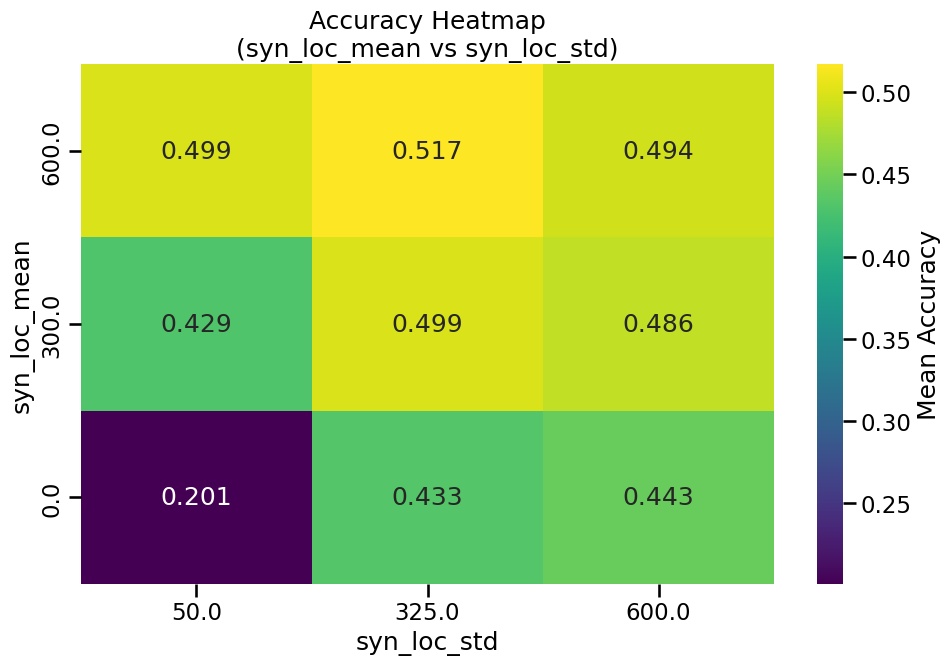

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_results(df):
    # 1. データが入っているかチェック
    if df.empty:
        print("Error: DataFrame is empty. Please check your data collection path.")
        return

    # 2. 対象パラメータの存在確認（デバッグ用）
    target_params = ["syn_loc_mean", "syn_loc_std"]
    available_params = [p for p in target_params if p in df.columns]
    
    if not available_params:
        print(f"Error: Target parameters {target_params} not found in DataFrame.")
        print(f"Available columns are: {list(df.columns)}")
        return

    # 3. スイープ（2種類以上の値がある）されているパラメータを特定
    sweep_params = [p for p in available_params if df[p].nunique() > 1]
    
    plt.figure(figsize=(10, 7))
    sns.set_context("talk") # 論文や発表で見やすい文字サイズに設定

    # --- パターンA: 2変数スイープ (ヒートマップ) ---
    if len(sweep_params) >= 2:
        print(f"Plotting 2D Sweep Heatmap: {sweep_params[0]} vs {sweep_params[1]}")
        # シード間の平均精度を算出
        pivot_df = df.groupby([sweep_params[0], sweep_params[1]])['accuracy'].mean().unstack()
        
        sns.heatmap(pivot_df, annot=True, cmap="viridis", fmt=".3f",
                    cbar_kws={'label': 'Mean Accuracy'})
        plt.gca().invert_yaxis()  # 平均が下から上に大きくなるように調整
        plt.title(f"Accuracy Heatmap\n({sweep_params[0]} vs {sweep_params[1]})")

    # --- パターンB: 1変数スイープ (折れ線グラフ) ---
    elif len(sweep_params) == 1:
        param = sweep_params[0]
        print(f"Plotting 1D Sweep Lineplot: {param}")
        # エラーバー（標準偏差 sd）を表示
        sns.lineplot(data=df, x=param, y="accuracy", marker='o', 
                     errorbar='sd', err_style="bars")
        plt.title(f"Accuracy vs {param}\n(Mean ± Standard Deviation)")
        plt.grid(True, linestyle='--', alpha=0.6)

    # --- パターンC: 全て固定値、またはシードのみの違い (箱ひげ図) ---
    else:
        print("Plotting Distribution for Fixed Parameters")
        sns.boxplot(data=df, y="accuracy", color="skyblue")
        sns.stripplot(data=df, y="accuracy", color="black", alpha=0.5)
        plt.title("Accuracy Distribution")

    plt.tight_layout()
    plt.savefig('position-accuracy.png')
    plt.show()

# 使い方
plot_results(df)